<a href="https://colab.research.google.com/github/michael-zhang0/A03-knn/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sihan Michael Zhang

**Date:** 10/2/26

In [7]:
# Your Phase 1 solution to the problem goes here.
# Q1.1
# Regression predicts a numerical value, classification predicts a category

# Q1.2
# A confusion table or confusion matrix is used to compare the actual class to
# the predicted class for a classification model. It can help us understand
# certain metrics like accuracy or precision of a data set by taking different
# fractions of true positives, true negatives, false positives, and false
# negatives. For example, accuracy is all true values over all the values.
# Accuracy = (TP + TN) / (TP + TN + FP + FN)

# Q1.3
# SSE or Sum of Squared Error quantifies the validation error of a model.

# Q1.4
# Overfitting is when a model is learning too many patterns of the data it is
# trained on, essentially memorizing data points and what goes where instead of
# generalizing a pattern. Underfitting is the opposite, where a model fails to
# learn the patterns in data due to the model architecture being too simple.
# Both cases fail to generalize patterns in unseen data.

# Q1.5
# We choose k after evaluating SSE on the test set because we can compare SSE
# values if we fit a model for each k value and then choose the k value that
# results in the lowest SSE. We use validation SSE because training SSE favors
# smaller k values due to predictions closely following the training data. Model
# performance is improved because we choose the k value that minimizes SSE for
# predictions on unseen data.

# Q1.6
# The strengths of reporting a class label directly are that it provides a more
# direct answer and is easier to evaluate metrics from a confusion matrix since
# they fit directly into one of the four (TP,TN,FP,FN). The weaknesses of
# reporting a class label directly are that it loses the uncertainty of a
# prediction, since a 51% looks the same as a 100%. The strengths of a
# probability distribution are that it preserves the model's uncertainty, as you
# can see directly what it thinks the chances of each class label are, and being
# able to shift the threshold for prediction certainty, like needing a certain
# percentage for something to categorize as that. Its weaknesses are that it is
# more complex to maintain, as you must maintain a percentage for each
# prediction rather than just a label, and they are harder to evaluate.

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
5  0.240966  0.727273   0.0          1
6  0.254410  0.818182   0.0          1
7  0.234924  1.000000   0.0          1
8  0.353474  0.000000   0.6          1
9  0.335347  0.181818   0.6          1
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
mine_type
1 

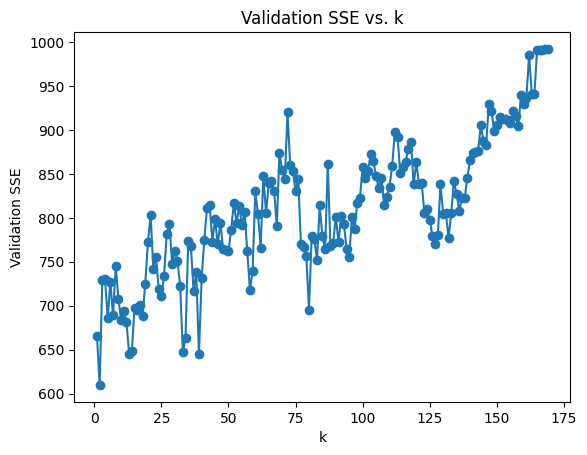

Predicted   1   2   3  4  5
Actual                     
1          18   1  12  3  1
2           0  29   1  5  0
3           7   1  16  8  1
4          15   5  10  3  0
5          14   1  14  2  2
Accuracy: 0.40236686390532544
Accuracy (%): 40.23668639053255
Actual
1    0.514286
2    0.828571
3    0.484848
4    0.090909
5    0.060606
dtype: float64
Most accurate class: 2
Least accurate class: 5


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

df = pd.read_csv('./data/land_mines.csv')

# Q2.1
# The landmine dataset has 338 observations with three features, voltage,
# height, and soil, and the target variable, mine_type. There are no missing
# values in the dataset. The target has five classes and is quite balanced, with
# roughly 20% of each type in the 5 classes. The other features have already
# been normalized in the range 0 to 1, which is helpful for kNN because no
# feature will domination the distance calculation based on just scale.
print(df.head(10))
print(df.describe())
print(df.isna().sum())
print(df["mine_type"].value_counts(normalize=True).sort_index())

# Q2.2
# Split the data 50/50 into training and testing
x = df[["voltage", "height", "soil"]]
y = df["mine_type"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.50,
                                                    random_state=1,stratify=y)
print("Training size:", len(x_train))
print("Test size:", len(x_test))

# Q2.3
# Build kNN classifier, select k based on lowest validation SSE, k=2
sse_values = []
k_values = range(1, 170)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    sse = np.sum((y_test - y_pred) ** 2)
    sse_values.append(sse)

best_k = k_values[np.argmin(sse_values)]

print("Best k:", best_k)
print("Lowest validation SSE:", min(sse_values))

plt.plot(k_values, sse_values, marker="o")
plt.xlabel("k")
plt.ylabel("Validation SSE")
plt.title("Validation SSE vs. k")
plt.show()

best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(x_train, y_train)
y_pred = best_knn.predict(x_test)
best_k = k_values[np.argmin(sse_values)]

# Q2.4
# The optimal kNN model used k = 2 and achieved an accuracy of 40% on the test
# set. The model performed best for mine type 2 with an accuracy of 82.86%,
# and worst for type 5 with an accuracy of 6.06%.
confusion = pd.crosstab(
    y_test,
    y_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)
print(confusion)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)
class_accuracy = np.diag(confusion) / confusion.sum(axis=1)
print(class_accuracy)
print("Most accurate class:", class_accuracy.idxmax())
print("Least accurate class:", class_accuracy.idxmin())

# Q2.5
# I would not use this model as the only method for identifying a mine because
# it still makes a lot of classification errors. Even if it predicts many mines
# right for one type, it may incorrectly label other mines as that type. I would
# use this model as a screening tool and not a final decision-maker. Predictions
# should be confirmed by a human and extra caution should be used for mine types
# that the confusion matrix frequently confused.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:**
- **AI tool and model used:**

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]